# Fruit Classification - 02: Transfer Learning

A frozen ImageNet-pretrained ResNet18 maps every image to a 512-dimensional feature vector. We then train a logistic-regression classifier on those features (a stratified 70/30 train/test split). No fine-tuning of the CNN, no training loop, just feature extraction + a linear model.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
from sklearn.model_selection import train_test_split
device = utils.get_device(); print('device:', device)
imgs, labels, classes = utils.load_sample()
print(len(imgs), 'images,', len(classes), 'classes')

device: mps


1124 images, 8 classes


## 1. Extract ResNet18 features

In [2]:
net = utils.build_extractor(device)
X = utils.extract_features(net, imgs, device)
y = np.array(labels)
print('feature matrix:', X.shape)

feature matrix: (1124, 512)


## 2. Train / test split and fit a linear classifier

In [3]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = utils.train_classifier(Xtr, ytr)
acc, cm, preds = utils.evaluate(clf, Xte, yte, classes)
print('TEST ACCURACY: %.4f  (%d / %d)' % (acc, int(round(acc*len(yte))), len(yte)))

TEST ACCURACY: 1.0000  (338 / 338)


## 3. Confusion matrix

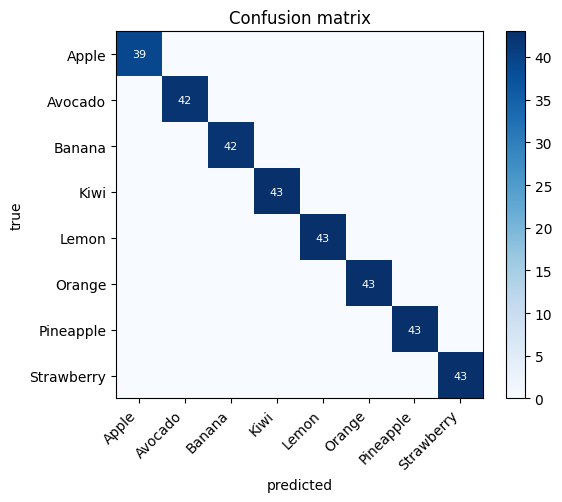

In [4]:
plt.figure(figsize=(6,5)); plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i,j]: plt.text(j,i,cm[i,j],ha='center',va='center',fontsize=8,color='black' if cm[i,j]<cm.max()/2 else 'white')
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix'); plt.tight_layout(); plt.show()

## 4. Per-class accuracy

In [5]:
for i,cls in enumerate(classes):
    tot = cm[i].sum()
    if tot: print('%-14s %.2f  (%d/%d)' % (cls, cm[i,i]/tot, cm[i,i], tot))

Apple          1.00  (39/39)
Avocado        1.00  (42/42)
Banana         1.00  (42/42)
Kiwi           1.00  (43/43)
Lemon          1.00  (43/43)
Orange         1.00  (43/43)
Pineapple      1.00  (43/43)
Strawberry     1.00  (43/43)


## 5. Sample predictions (red = wrong)

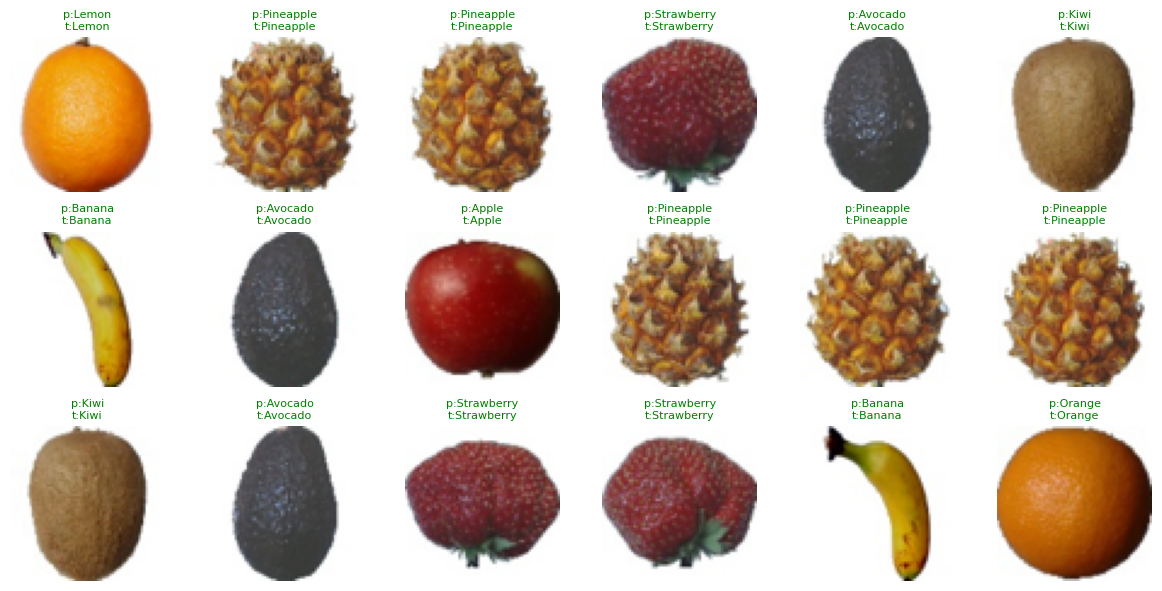

In [6]:
import numpy as np
# rebuild test images by re-splitting indices the same way
idx_all = np.arange(len(imgs))
from sklearn.model_selection import train_test_split as tts
_, idx_te = tts(idx_all, test_size=0.3, random_state=42, stratify=y)
show = idx_te[:18]
fig, ax = plt.subplots(3,6, figsize=(12,6))
for a,i in zip(ax.ravel(), show):
    a.imshow(imgs[i]); a.axis('off')
    pr = clf.predict(X[i:i+1])[0]
    a.set_title('p:%s\nt:%s' % (pr, y[i]), color='green' if pr==y[i] else 'red', fontsize=8)
plt.tight_layout(); plt.show()

### Findings
ResNet18 features plus a linear classifier separate the fruit classes with very high accuracy, even though the CNN was never trained on fruit and we never fine-tuned it. Clean, well-lit, single-object images are exactly where frozen ImageNet features shine. Compare this with the Animal Species project, where the same recipe on messy 32x32 photos scores much lower.